In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\tejas\Downloads\FINAL_DATASET.csv")
print(df.head())


   image_id                                          image_url label  \
0         1  https://images.unsplash.com/photo-172422561835...  REAL   
1         2  https://images.unsplash.com/photo-172422561873...  REAL   
2         3  https://images.unsplash.com/photo-172422561834...  REAL   
3         4  https://images.unsplash.com/photo-172422561855...  REAL   
4         5  https://images.unsplash.com/photo-172422561823...  REAL   

   label_numeric   category  gender age_group    source fake_method  \
0              1  Authentic  Female     18-25  Unsplash         NaN   
1              1  Authentic    Male       50+  Unsplash         NaN   
2              1  Authentic  Female     36-50  Unsplash         NaN   
3              1  Authentic  Female     26-35  Unsplash         NaN   
4              1  Authentic    Male     36-50  Unsplash         NaN   

  image_quality resolution  confidence_score detection_difficulty  \
0          High  1080x1080              0.96                 Easy   
1 

In [5]:
df['date_collected'] = pd.to_datetime(df['date_collected'], errors='coerce')

resolution_parts = df['resolution'].astype(str).str.extract(r'(\d+)x(\d+)')
df['res_width'] = pd.to_numeric(resolution_parts[0], errors='coerce')
df['res_height'] = pd.to_numeric(resolution_parts[1], errors='coerce')
df['pixel_count'] = df['res_width'] * df['res_height']


In [6]:
print(df.shape)
print(df.isna().sum().sort_values(ascending=False).head(10))

num_summary = df.select_dtypes(include=[np.number]).describe()
print(num_summary)

cat_cols = df.select_dtypes(exclude=[np.number, 'datetime']).columns
for col in cat_cols:
    print('\n')
    print(col)
    print(df[col].value_counts(dropna=False).head(10))


(6557, 20)
fake_method             2790
image_id                   0
confidence_score           0
res_height                 0
res_width                  0
year                       0
version                    0
date_collected             0
dataset_split              0
detection_difficulty       0
dtype: int64
         image_id  label_numeric  confidence_score    year    res_width  \
count  6557.00000    6557.000000       6557.000000  6557.0  6557.000000   
mean   3279.00000       0.425499          0.903741  2026.0  1047.827970   
std    1892.98719       0.494456          0.049982     0.0    27.689549   
min       1.00000       0.000000          0.800000  2026.0  1024.000000   
25%    1640.00000       0.000000          0.860000  2026.0  1024.000000   
50%    3279.00000       0.000000          0.910000  2026.0  1024.000000   
75%    4918.00000       1.000000          0.950000  2026.0  1080.000000   
max    6557.00000       1.000000          0.990000  2026.0  1080.000000   

        re

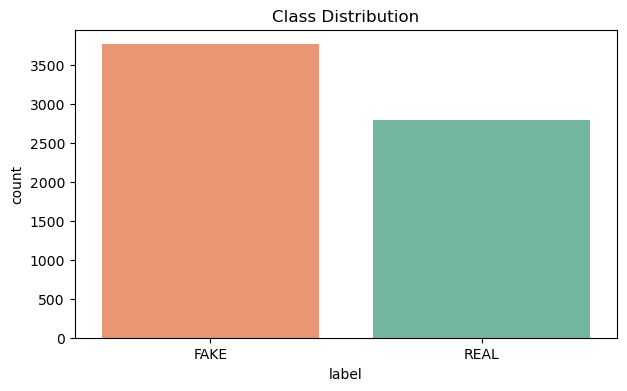

In [20]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='Set2',hue='label', 
    legend=False)
plt.title('Class Distribution')
plt.show()

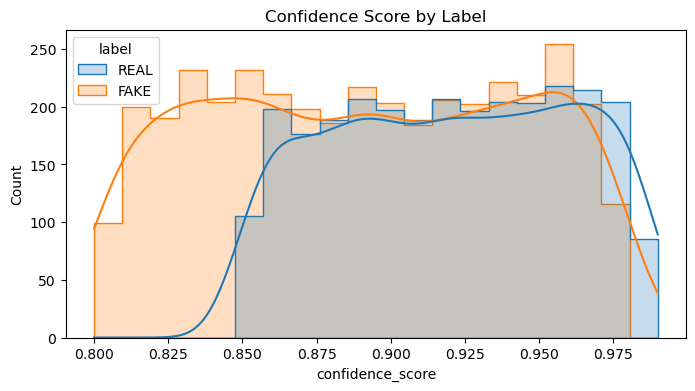

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='confidence_score', hue='label', bins=20, kde=True, element='step')
plt.title('Confidence Score by Label')
plt.show()

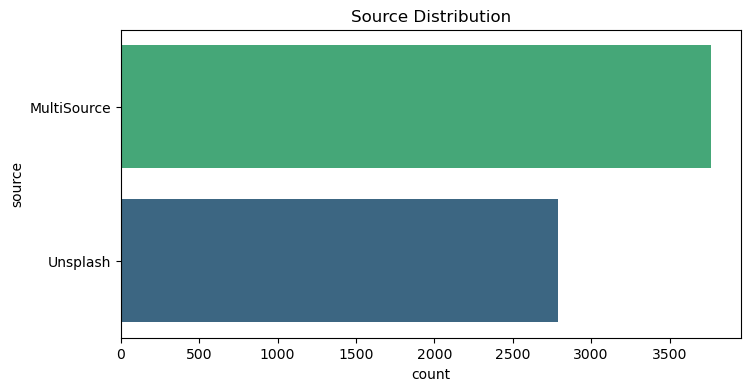

In [23]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='source', order=df['source'].value_counts().index, palette='viridis', hue='source', 
    legend=False)
plt.title('Source Distribution')
plt.show()

C:\Users\tejas\AppData\Local\Temp\ipykernel_13632\1949540325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='detection_difficulty', order=['Easy', 'Medium', 'Hard'], palette='coolwarm')


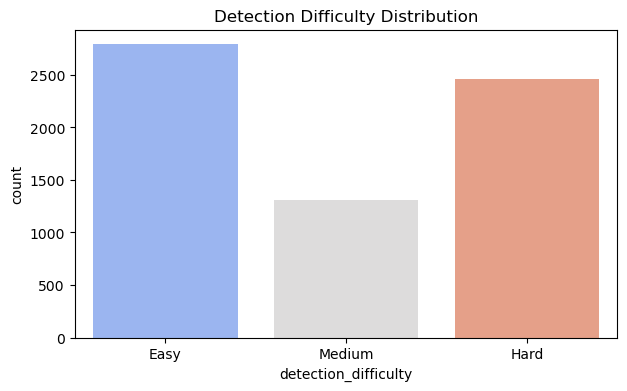

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='detection_difficulty', order=['Easy', 'Medium', 'Hard'], palette='coolwarm')
plt.title('Detection Difficulty Distribution')
plt.show()

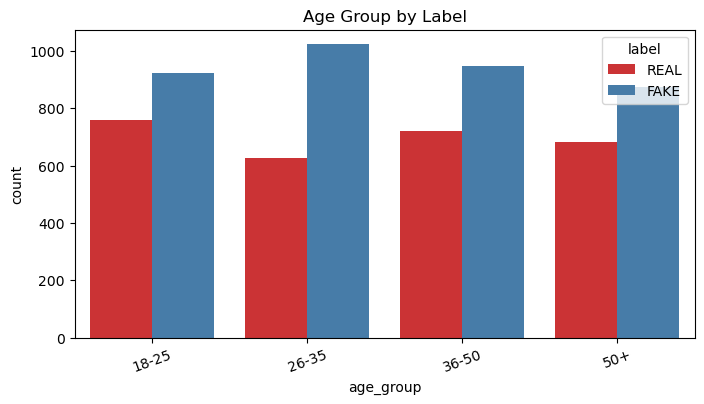

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='age_group', hue='label', order=['18-25', '26-35', '36-50', '50+'], palette='Set1')
plt.title('Age Group by Label')
plt.xticks(rotation=20)
plt.show()

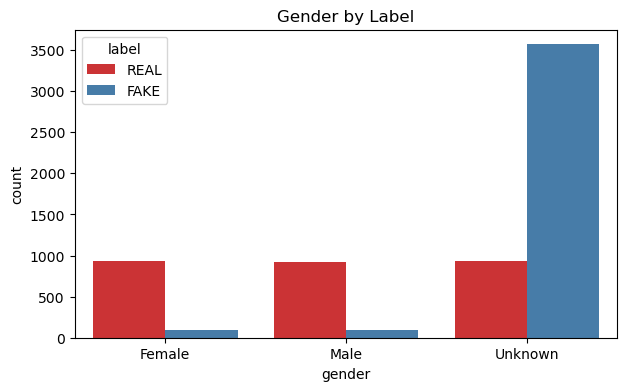

In [12]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='gender', hue='label', palette='Set1')
plt.title('Gender by Label')
plt.show()

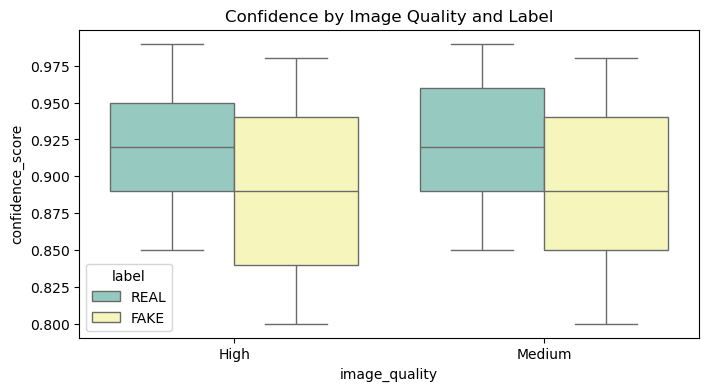

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='image_quality', y='confidence_score', hue='label', palette='Set3')
plt.title('Confidence by Image Quality and Label')
plt.show()

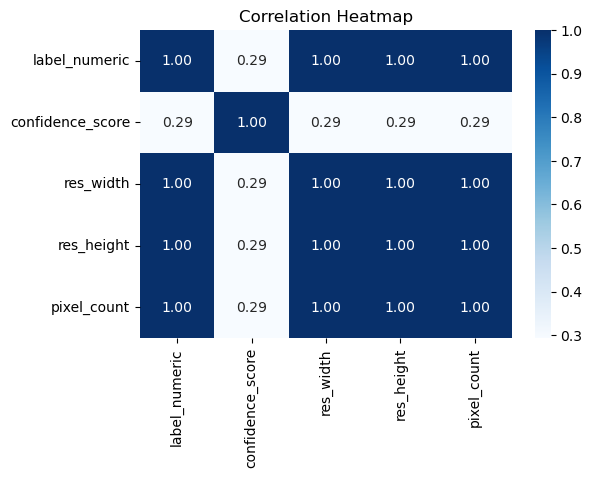

                  label_numeric  confidence_score  res_width  res_height  \
label_numeric          1.000000          0.293305   1.000000    1.000000   
confidence_score       0.293305          1.000000   0.293305    0.293305   
res_width              1.000000          0.293305   1.000000    1.000000   
res_height             1.000000          0.293305   1.000000    1.000000   
pixel_count            1.000000          0.293305   1.000000    1.000000   

                  pixel_count  
label_numeric        1.000000  
confidence_score     0.293305  
res_width            1.000000  
res_height           1.000000  
pixel_count          1.000000  


In [14]:
num_cols = ['label_numeric', 'confidence_score', 'res_width', 'res_height', 'pixel_count']
correlation_matrix = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print(correlation_matrix)

In [15]:
source_label_ct = pd.crosstab(df['source'], df['label'], normalize='index')
difficulty_label_ct = pd.crosstab(df['label'], df['detection_difficulty'], normalize='index')

print(source_label_ct)
print(difficulty_label_ct)

label        FAKE  REAL
source                 
MultiSource   1.0   0.0
Unsplash      0.0   1.0
detection_difficulty  Easy      Hard    Medium
label                                         
FAKE                   0.0  0.653305  0.346695
REAL                   1.0  0.000000  0.000000


In [16]:
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['label', 'count']
label_counts['percent'] = (label_counts['count'] / len(df) * 100).round(2)
print(label_counts)

quality_conf = df.groupby(['image_quality', 'label'])['confidence_score'].agg(['mean', 'median', 'count']).reset_index()
print(quality_conf)

source_conf = df.groupby('source')['confidence_score'].agg(['mean', 'count']).reset_index().sort_values('mean', ascending=False)
print(source_conf)

  label  count  percent
0  FAKE   3767    57.45
1  REAL   2790    42.55
  image_quality label      mean  median  count
0          High  FAKE  0.890552    0.89   2465
1          High  REAL  0.919851    0.92   1885
2        Medium  FAKE  0.892212    0.89   1302
3        Medium  REAL  0.922696    0.92    905
        source      mean  count
1     Unsplash  0.920774   2790
0  MultiSource  0.891126   3767


In [18]:
label_counts.to_csv('eda_label_distribution.csv', index=False)
quality_conf.to_csv('eda_quality_confidence_summary.csv', index=False)
source_conf.to_csv('eda_source_confidence_summary.csv', index=False)
correlation_matrix.to_csv('eda_correlation_matrix.csv')